# 골연령 데이터 성별 × 연령대(12개월 구간) 분포 확인

- `training.csv` / `validation.csv` / `test.csv` 의 컬럼명이 서로 달라서 **하나의 스키마(id, months, sex, split)** 로 정규화한 뒤 처리합니다.
- 구간은 **하한 미포함 / 상한 포함**: `(120, 132]` = 120.00001~132 (요청하신 방식)
- 결과: 성별×구간 교차표(건수/비율) + 그래프 4종 + CSV/XLSX 저장


In [1]:
# ── 0. 설치(최초 1회만) ────────────────────────────────
# !pip install pandas numpy matplotlib openpyxl

In [2]:
# ── 1. 임포트 & 설정 ──────────────────────────────────
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# 한글 폰트 자동 선택 (Windows: 맑은 고딕 / mac: AppleGothic / Linux: NanumGothic)
from matplotlib import font_manager
_installed = {f.name for f in font_manager.fontManager.ttflist}
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic"]:
    if _f in _installed:
        matplotlib.rc("font", family=_f)
        print("한글 폰트:", _f)
        break
else:
    print("⚠️ 한글 폰트 없음 → 그래프 한글이 깨질 수 있습니다.")
matplotlib.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_rows", 200)

# ⚠️ 여기만 본인 경로로 수정 (예: r"G:\Project\boneage\data")
DATA_DIR  = Path(r".")
OUT_DIR   = Path(r"./dist_out")      # 표/그래프 저장 폴더
BIN_WIDTH = 12                        # 구간 폭(개월)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 파일별 컬럼 스키마 (파일마다 헤더가 달라서 매핑 필요)
SPECS = {
    "train": dict(file="training.csv",   id_col="id",       age_col="boneage",                        sex_col="male"),
    "valid": dict(file="validation.csv", id_col="Image ID", age_col="Bone Age (months)",              sex_col="male"),
    "test":  dict(file="test.csv",       id_col="Case ID",  age_col="Ground truth bone age (months)", sex_col="Sex"),
}
SEX_ORDER   = ["M", "F"]
SEX_KR      = {"M": "남", "F": "여"}
SEX_COLOR   = {"M": "#3B76B8", "F": "#D45B7A"}
SPLIT_ORDER = list(SPECS)

한글 폰트: Malgun Gothic


In [3]:
# ── 2. 로드 & 스키마 정규화 ────────────────────────────
def normalize_sex(s: pd.Series) -> np.ndarray:
    """bool(True/False) 또는 문자열(M/F, Male/Female) 모두 'M'/'F'로 통일."""
    if pd.api.types.is_bool_dtype(s):
        return np.where(s.fillna(False), "M", "F")
    t = s.astype(str).str.strip().str.upper()
    return np.select(
        [t.isin(["M", "MALE", "TRUE", "1"]), t.isin(["F", "FEMALE", "FALSE", "0"])],
        ["M", "F"], default="UNK",
    )

def load_split(split: str, spec: dict) -> pd.DataFrame:
    path = DATA_DIR / spec["file"]
    if not path.exists():
        raise FileNotFoundError(f"파일 없음: {path.resolve()}  → DATA_DIR을 확인하세요.")
    # encoding='utf-8-sig' : validation/test 헤더에 BOM이 있어 필수
    raw = pd.read_csv(path, encoding="utf-8-sig")
    missing = [c for c in (spec["id_col"], spec["age_col"], spec["sex_col"]) if c not in raw.columns]
    if missing:
        raise KeyError(f"{spec['file']} 컬럼 불일치 {missing} / 실제 컬럼: {list(raw.columns)}")
    return pd.DataFrame({
        "split":  split,
        "id":     raw[spec["id_col"]],
        "months": pd.to_numeric(raw[spec["age_col"]], errors="coerce"),
        "sex":    normalize_sex(raw[spec["sex_col"]]),
    })

df = pd.concat([load_split(k, v) for k, v in SPECS.items()], ignore_index=True)

# 품질 점검
bad_age = df["months"].isna().sum()
bad_sex = (df["sex"] == "UNK").sum()
print(f"총 {len(df):,}행 | 나이 결측 {bad_age} | 성별 미상 {bad_sex}")
if bad_age or bad_sex:
    display(df[df["months"].isna() | (df["sex"] == "UNK")].head(20))
df = df.dropna(subset=["months"]).query("sex != 'UNK'").reset_index(drop=True)

print(df.groupby(["split", "sex"]).size().unstack("sex").reindex(SPLIT_ORDER))
df.head()

총 14,037행 | 나이 결측 0 | 성별 미상 0
sex       F     M
split            
train  5697  6744
valid   638   761
test     99    98


,split,id,months,sex
0,train,1377,180.0,F
1,train,1378,12.0,F
2,train,1379,94.0,F
3,train,1380,120.0,M
4,train,1381,82.0,F


In [4]:
# ── 3. 12개월 단위 구간화 (하한 미포함, 상한 포함) ───────
mx    = float(df["months"].max())
edges = np.arange(0, np.ceil(mx / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
labels = [f"{int(edges[i])}~{int(edges[i+1])}" for i in range(len(edges) - 1)]

# right=True, include_lowest=False → (0,12], (12,24], ... (120,132] 형태
df["age_bin"] = pd.cut(df["months"], bins=edges, right=True,
                       include_lowest=False, labels=labels, ordered=True)

assert df["age_bin"].isna().sum() == 0, "구간에 안 들어간 값 존재 → edges 범위 확인"
print(f"최대 {mx:.2f}개월 / 구간 {len(labels)}개: {labels[0]} ... {labels[-1]}")
print("예시) 120 → ", pd.cut([120.0], bins=edges, right=True, labels=labels)[0],
      " | 120.5 → ", pd.cut([120.5], bins=edges, right=True, labels=labels)[0])

최대 228.00개월 / 구간 19개: 0~12 ... 216~228
예시) 120 →  108~120  | 120.5 →  120~132


In [5]:
# ── 4. 분포표 (건수 + 비율) ────────────────────────────
def dist_table(sub: pd.DataFrame, drop_empty=True) -> pd.DataFrame:
    t = pd.crosstab(sub["age_bin"], sub["sex"]).reindex(index=labels, fill_value=0)
    t = t.reindex(columns=SEX_ORDER, fill_value=0)
    t.columns = [SEX_KR[c] for c in t.columns]
    t["합계"] = t.sum(axis=1)
    if drop_empty:
        t = t[t["합계"] > 0]
    t["비율%"]   = (t["합계"] / t["합계"].sum() * 100).round(2)
    t["남비율%"] = (t["남"] / t["합계"].replace(0, np.nan) * 100).round(1)
    total = pd.DataFrame(
        [[t["남"].sum(), t["여"].sum(), t["합계"].sum(), 100.0,
          round(t["남"].sum() / t["합계"].sum() * 100, 1)]],
        columns=t.columns, index=["총계"],
    )
    return pd.concat([t, total])

tables = {}
for sp in SPLIT_ORDER:
    tables[sp] = dist_table(df[df["split"] == sp])
    print(f"\n{'='*46}\n[{sp}]  n={len(df[df['split']==sp]):,}\n{'='*46}")
    display(tables[sp])

# 기술통계 (성별 × split)
stats = (df.groupby(["split", "sex"])["months"]
           .agg(n="count", 평균="mean", 표준편차="std", 최소="min",
                중앙="median", 최대="max").round(2)
           .reindex(SPLIT_ORDER, level=0))
display(stats)


[train]  n=12,441


,남,여,합계,비율%,남비율%
0~12,12,10,22,0.18,54.5
12~24,75,54,129,1.04,58.1
24~36,76,121,197,1.58,38.6
36~48,127,64,191,1.54,66.5
48~60,259,244,503,4.04,51.5
60~72,268,232,500,4.02,53.6
72~84,286,465,751,6.04,38.1
84~96,294,601,895,7.19,32.8
96~108,363,535,898,7.22,40.4
108~120,410,700,1110,8.92,36.9



[valid]  n=1,399


,남,여,합계,비율%,남비율%
0~12,2,0,2,0.14,100.0
12~24,10,11,21,1.50,47.6
24~36,7,9,16,1.14,43.8
36~48,16,12,28,2.00,57.1
48~60,29,24,53,3.79,54.7
60~72,28,28,56,4.00,50.0
72~84,34,48,82,5.86,41.5
84~96,30,72,102,7.29,29.4
96~108,46,61,107,7.65,43.0
108~120,49,75,124,8.86,39.5



[test]  n=197


,남,여,합계,비율%,남비율%
12~24,0,2,2,1.02,0.0
24~36,2,2,4,2.03,50.0
36~48,0,3,3,1.52,0.0
48~60,1,3,4,2.03,25.0
60~72,5,2,7,3.55,71.4
72~84,4,6,10,5.08,40.0
84~96,3,10,13,6.60,23.1
96~108,4,4,8,4.06,50.0
108~120,6,8,14,7.11,42.9
120~132,5,10,15,7.61,33.3


n      평균   표준편차     최소      중앙      최대
split sex                                            
train F    5697  118.03  37.63   4.00  120.00  216.00
      M    6744  135.45  41.92   1.00  150.00  228.00
valid F     638  118.07  38.43  14.00  120.00  228.00
      M     761  135.11  42.31   6.00  150.00  228.00
test  F      99  124.04  42.85  17.97  130.45  199.34
      M      98  141.55  40.58  24.53  149.72  219.06

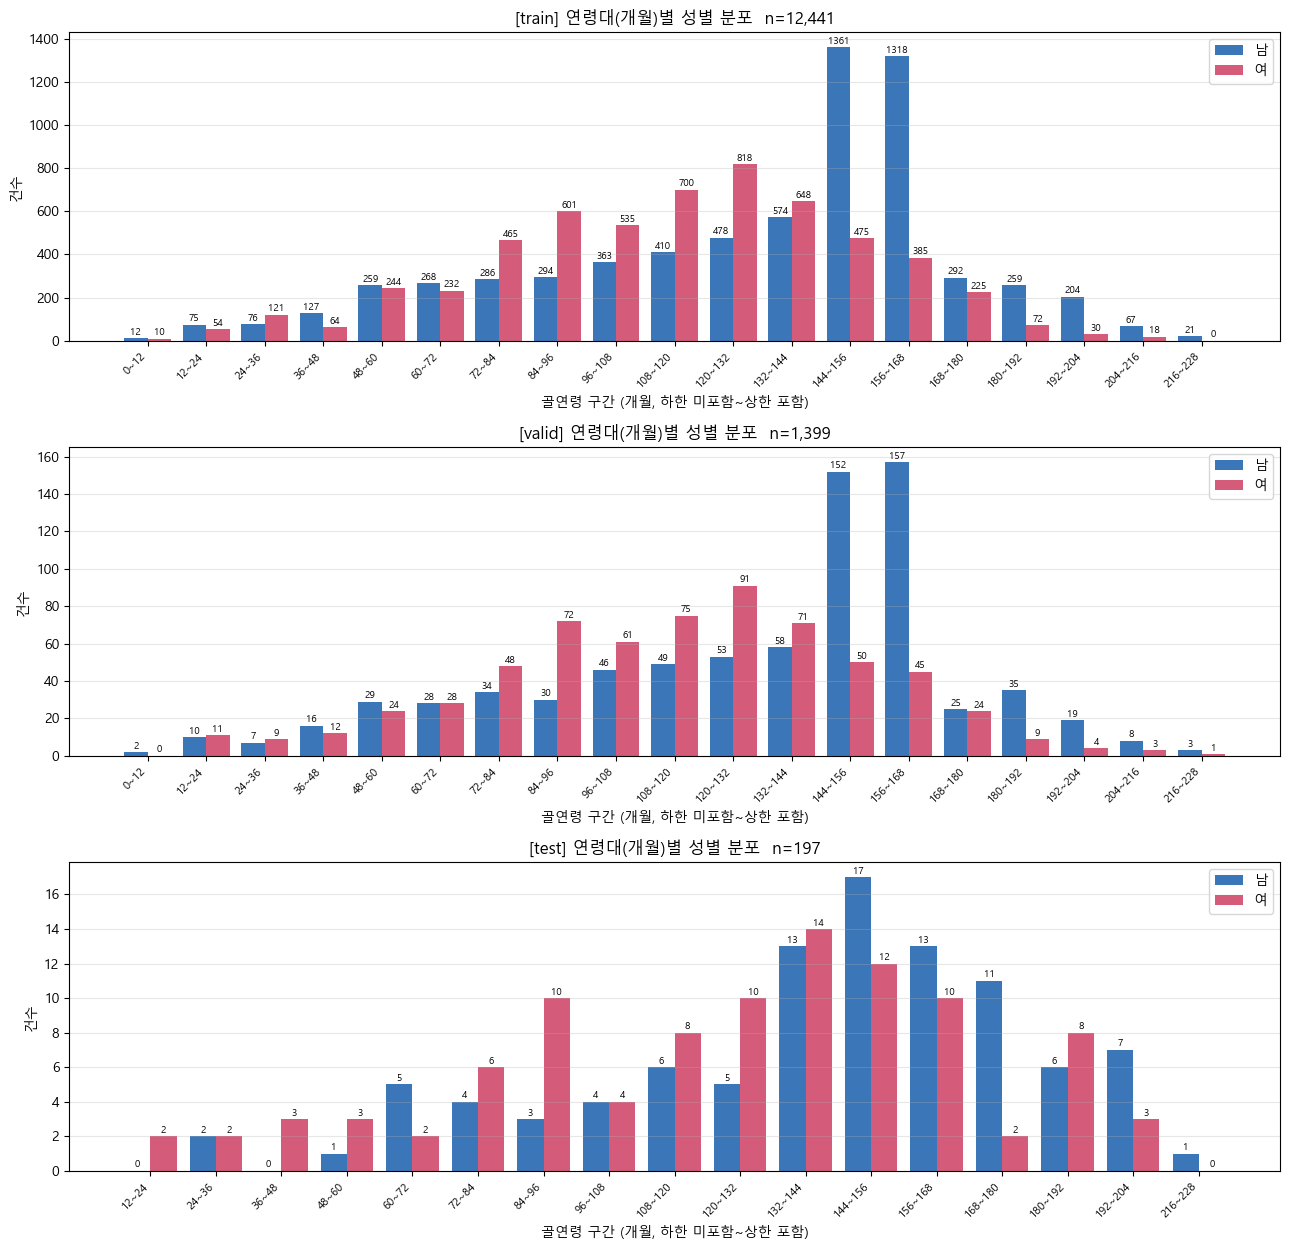

In [6]:
# ── 5. 그래프 A: split별 성별 그룹 막대 ─────────────────
fig, axes = plt.subplots(len(SPLIT_ORDER), 1, figsize=(13, 4.2 * len(SPLIT_ORDER)))
for ax, sp in zip(np.atleast_1d(axes), SPLIT_ORDER):
    sub = df[df["split"] == sp]
    piv = (pd.crosstab(sub["age_bin"], sub["sex"])
             .reindex(index=labels, fill_value=0).reindex(columns=SEX_ORDER, fill_value=0))
    piv = piv[piv.sum(axis=1) > 0]
    x, w = np.arange(len(piv)), 0.4
    for i, s in enumerate(SEX_ORDER):
        b = ax.bar(x + (i - 0.5) * w, piv[s], w, label=SEX_KR[s], color=SEX_COLOR[s])
        ax.bar_label(b, fontsize=7, padding=1)
    ax.set_xticks(x); ax.set_xticklabels(piv.index, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"[{sp}] 연령대(개월)별 성별 분포  n={len(sub):,}", fontsize=12)
    ax.set_xlabel("골연령 구간 (개월, 하한 미포함~상한 포함)"); ax.set_ylabel("건수")
    ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "01_split별_성별분포.png", dpi=150, bbox_inches="tight")
plt.show()

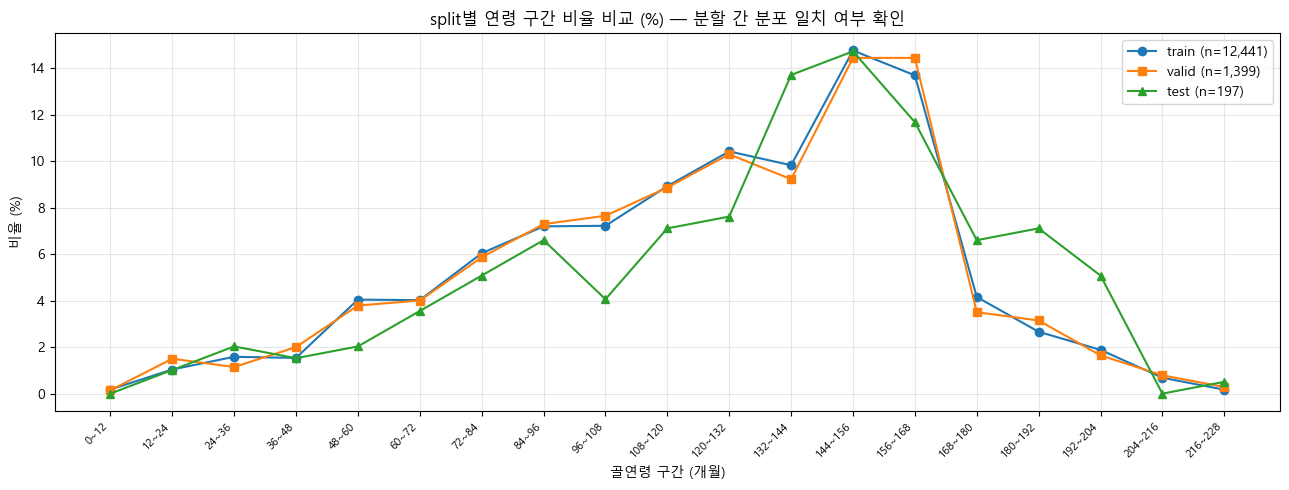

In [7]:
# ── 6. 그래프 B: split 간 분포 비교(비율 %) ─────────────
fig, ax = plt.subplots(figsize=(13, 5))
used = [l for l in labels if (df["age_bin"] == l).any()]
for sp, mk in zip(SPLIT_ORDER, ["o", "s", "^"]):
    r = (df[df["split"] == sp]["age_bin"].value_counts(normalize=True)
           .reindex(used, fill_value=0) * 100)
    ax.plot(used, r.values, marker=mk, label=f"{sp} (n={(df['split']==sp).sum():,})")
ax.set_title("split별 연령 구간 비율 비교 (%) — 분할 간 분포 일치 여부 확인")
ax.set_xlabel("골연령 구간 (개월)"); ax.set_ylabel("비율 (%)")
plt.xticks(rotation=45, ha="right", fontsize=8)
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "02_split간_비율비교.png", dpi=150, bbox_inches="tight")
plt.show()

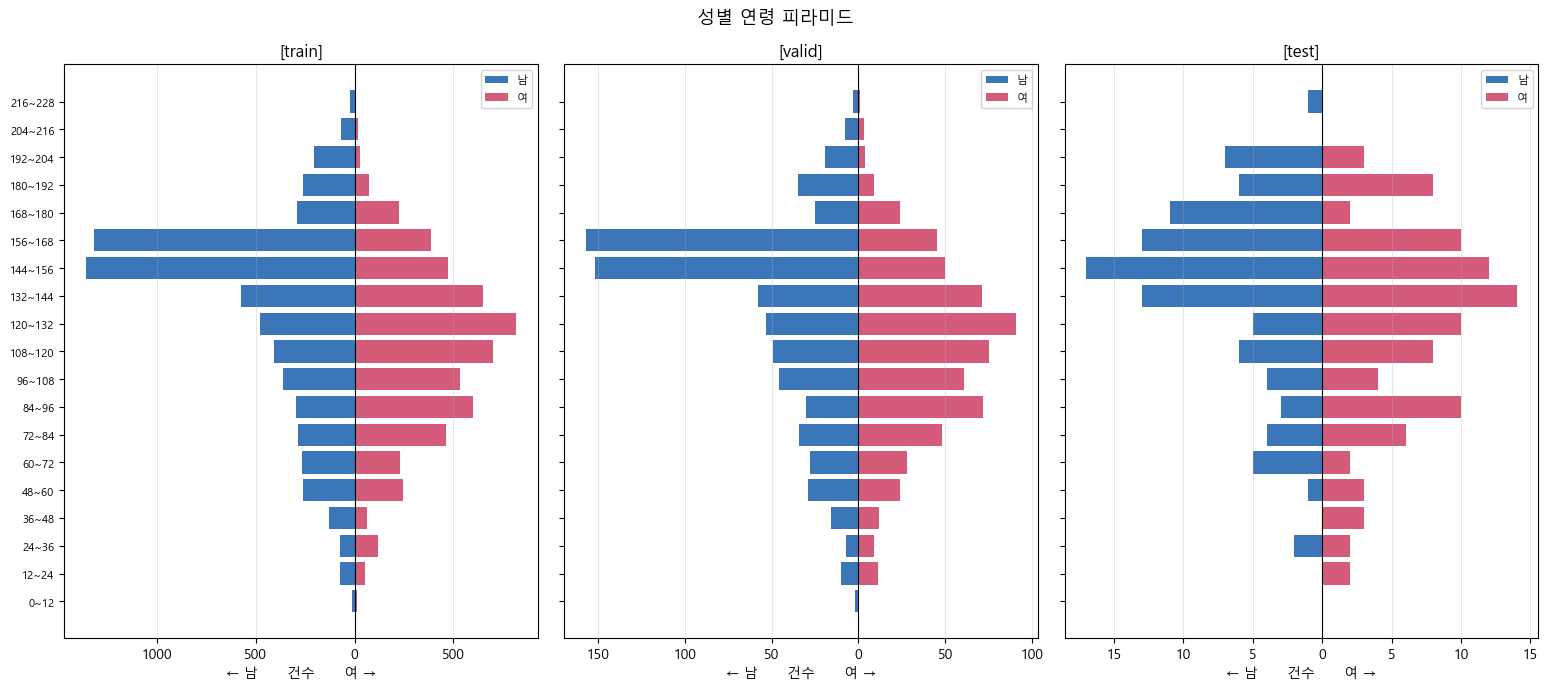

In [8]:
# ── 7. 그래프 C: 인구 피라미드(남 좌 / 여 우) ────────────
fig, axes = plt.subplots(1, len(SPLIT_ORDER), figsize=(5.2 * len(SPLIT_ORDER), 7), sharey=True)
for ax, sp in zip(np.atleast_1d(axes), SPLIT_ORDER):
    sub = df[df["split"] == sp]
    piv = (pd.crosstab(sub["age_bin"], sub["sex"])
             .reindex(index=labels, fill_value=0).reindex(columns=SEX_ORDER, fill_value=0))
    y = np.arange(len(piv))
    ax.barh(y, -piv["M"], color=SEX_COLOR["M"], label="남")
    ax.barh(y,  piv["F"], color=SEX_COLOR["F"], label="여")
    ax.set_yticks(y); ax.set_yticklabels(piv.index, fontsize=8)
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"[{sp}]"); ax.set_xlabel("← 남      건수      여 →")
    ax.xaxis.set_major_formatter(lambda v, p: f"{abs(int(v))}")
    ax.grid(axis="x", alpha=.3); ax.legend(fontsize=8)
plt.suptitle("성별 연령 피라미드", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "03_성별_피라미드.png", dpi=150, bbox_inches="tight")
plt.show()

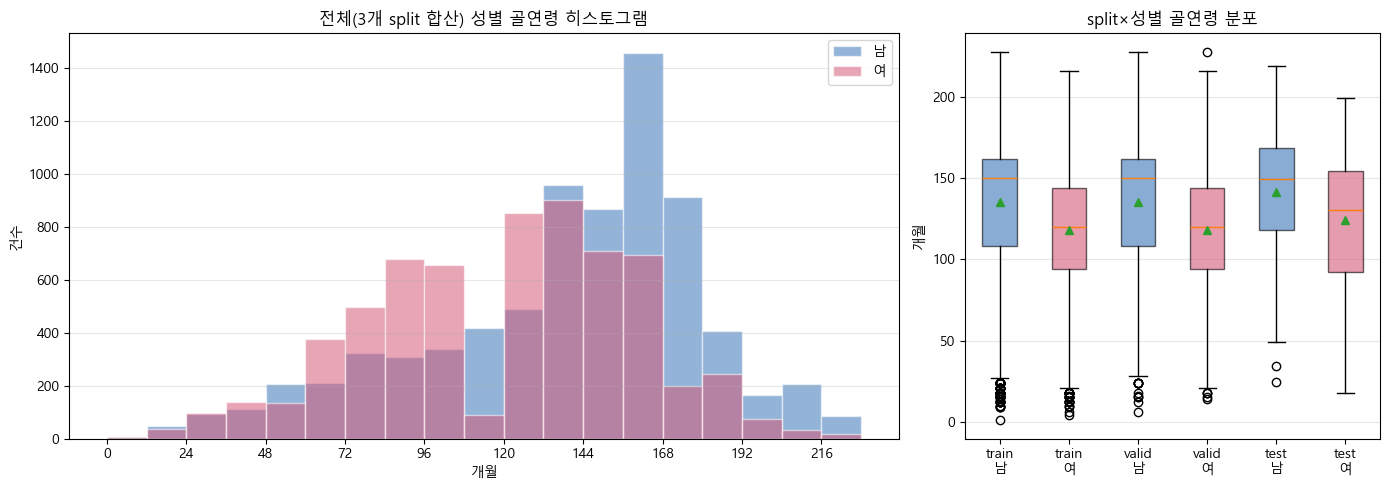

In [9]:
# ── 8. 그래프 D: 성별 히스토그램 + 박스플롯 ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2, 1]})
for s in SEX_ORDER:
    axes[0].hist(df[df["sex"] == s]["months"], bins=edges, alpha=.55,
                 label=SEX_KR[s], color=SEX_COLOR[s], edgecolor="white")
axes[0].set_title("전체(3개 split 합산) 성별 골연령 히스토그램")
axes[0].set_xlabel("개월"); axes[0].set_ylabel("건수")
axes[0].set_xticks(edges[::2]); axes[0].legend(); axes[0].grid(axis="y", alpha=.3)

data  = [df[(df.split == sp) & (df.sex == s)]["months"] for sp in SPLIT_ORDER for s in SEX_ORDER]
names = [f"{sp}\n{SEX_KR[s]}" for sp in SPLIT_ORDER for s in SEX_ORDER]
try:   # matplotlib >= 3.9
    bp = axes[1].boxplot(data, tick_labels=names, patch_artist=True, showmeans=True)
except TypeError:
    bp = axes[1].boxplot(data, labels=names, patch_artist=True, showmeans=True)
for patch, s in zip(bp["boxes"], [s for _ in SPLIT_ORDER for s in SEX_ORDER]):
    patch.set_facecolor(SEX_COLOR[s]); patch.set_alpha(.6)
axes[1].set_title("split×성별 골연령 분포"); axes[1].set_ylabel("개월")
axes[1].grid(axis="y", alpha=.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "04_히스토그램_박스플롯.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── 9. 결과 저장 (CSV + XLSX 한 파일) ───────────────────
for sp, t in tables.items():
    t.to_csv(OUT_DIR / f"dist_{sp}.csv", encoding="utf-8-sig")
df.to_csv(OUT_DIR / "all_with_bins.csv", index=False, encoding="utf-8-sig")

try:
    with pd.ExcelWriter(OUT_DIR / "boneage_distribution.xlsx", engine="openpyxl") as w:
        for sp, t in tables.items():
            t.to_excel(w, sheet_name=sp)
        stats.to_excel(w, sheet_name="stats")
    print("저장 완료:", (OUT_DIR / "boneage_distribution.xlsx").resolve())
except ModuleNotFoundError:
    print("openpyxl 미설치 → CSV만 저장됨 (pip install openpyxl)")

print("출력 폴더:", OUT_DIR.resolve())

저장 완료: C:\Project\PythonProject\PyTorch001\final_project\bone\dist_out\boneage_distribution.xlsx
출력 폴더: C:\Project\PythonProject\PyTorch001\final_project\bone\dist_out
